Dataset loaded successfully!

First 5 Rows:
  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  11-08-2017  North   1254      0.12  401.28  Tamil Nadu  
1  11-08-2017  South    749      0.18  149.80  Tamil Nadu  
2  06-12-2017   West   2360      0.21  165.20  Tamil Nadu  
3  10-11-2016  South    896      0.25   89.60  Tamil Nadu  
4  10-11-2016  South   2355      0.26  918.45  Tamil Nadu  

Dataset Shape:
(9994, 11)

Column Names:
['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', '

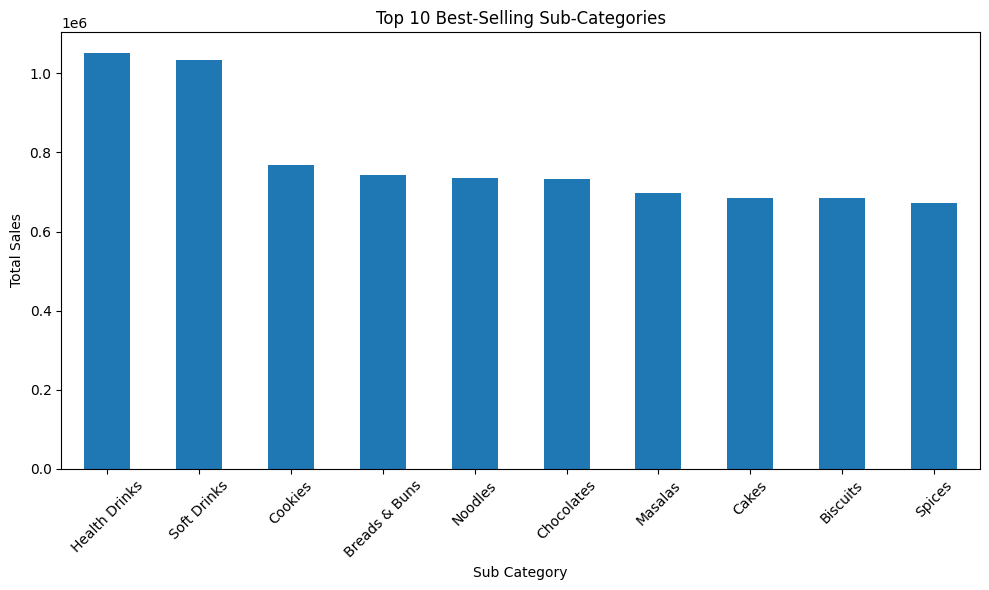

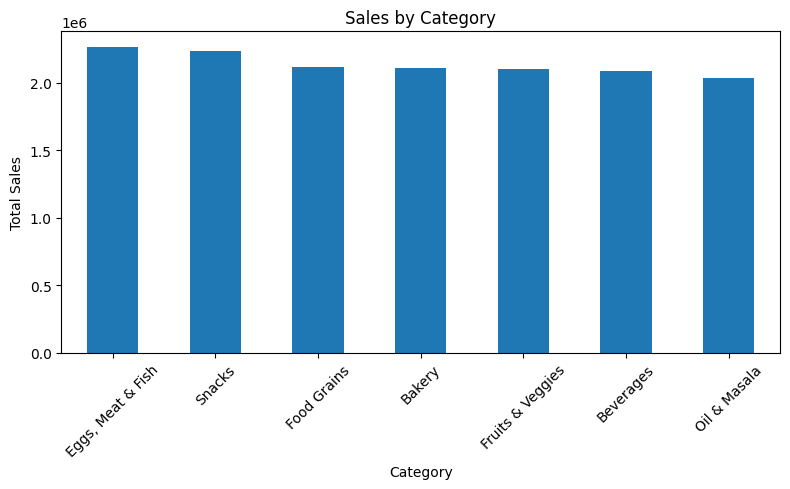

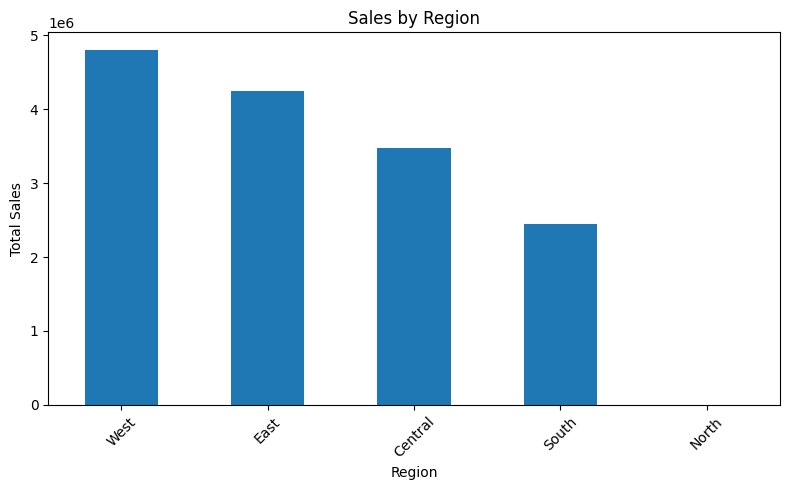

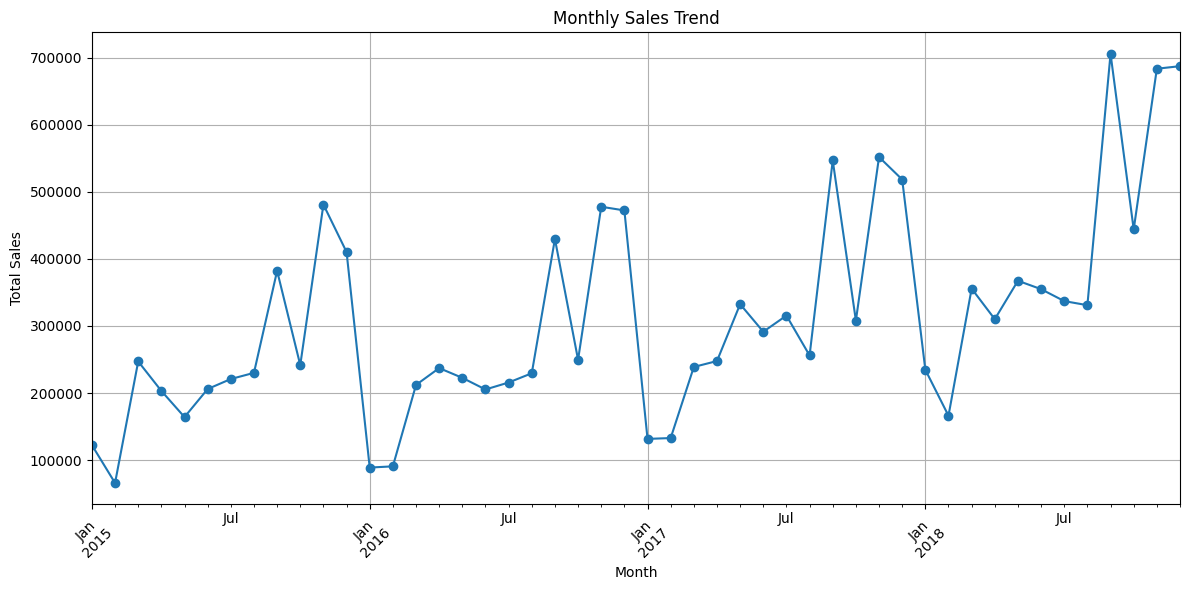

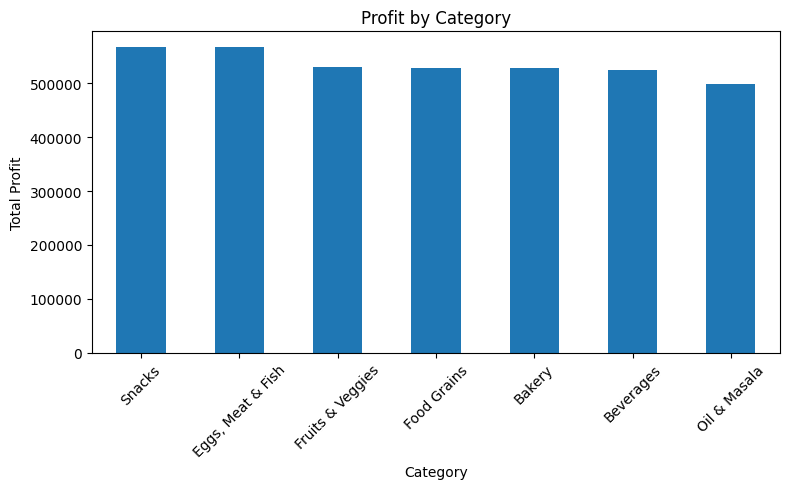



FINAL BUSINESS INSIGHTS

1. Total Sales: 14956982

2. Total Profit: 3747121.2

3. Best-Selling Category: Eggs, Meat & Fish

4. Best-Selling Sub-Category: Health Drinks

5. Highest-Sales Region: West

6. Highest-Sales State: Tamil Nadu

7. Most Profitable Category: Snacks

8. Average Sales per Order: 1496.6

9. Top 5 Selling Sub-Categories:
Sub Category
Health Drinks    1051439
Soft Drinks      1033874
Cookies           768213
Breads & Buns     742586
Noodles           735435
Name: Sales, dtype: int64

TASK 1 ANALYSIS COMPLETED SUCCESSFULLY!


In [4]:
# TERNOVATE INTERNSHIP - TASK 1
# SALES DATA ANALYSIS

# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Dataset
file_path = r"C:\Users\Suresh seervi\Desktop\ternovate\Supermart Grocery Sales - Retail Analytics Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("=" * 60)


# 3. Basic Data Inspection

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


# 4. Check Missing Values


print("\nMissing Values:")
print(df.isnull().sum())


# 5. Check and Remove Duplicate Rows

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(df.shape)


# 6. Convert Order Date to DateTime

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    errors="coerce"
)

print("\nDate Conversion Completed!")

print("\nInvalid Dates:")
print(df["Order Date"].isna().sum())


# 7. Basic Sales Analysis

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("\n" + "=" * 60)
print("BASIC SALES ANALYSIS")
print("=" * 60)

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))


# 8. Sales by Category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("SALES BY CATEGORY")
print("=" * 60)

print(category_sales)

top_category = category_sales.idxmax()

print("\nTop Selling Category:", top_category)
print("Sales:", round(category_sales.max(), 2))


# 9. Sales by Sub-Category

subcategory_sales = (
    df.groupby("Sub Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("SALES BY SUB-CATEGORY")
print("=" * 60)

print(subcategory_sales)

print("\nTop 5 Selling Sub-Categories:")
print(subcategory_sales.head(5))

top_subcategory = subcategory_sales.idxmax()

print("\nBest Selling Sub-Category:", top_subcategory)


# 10. Profit by Category


category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("PROFIT BY CATEGORY")
print("=" * 60)

print(category_profit)

most_profitable_category = category_profit.idxmax()

print("\nMost Profitable Category:",
      most_profitable_category)


# 11. Profit by Sub-Category


subcategory_profit = (
    df.groupby("Sub Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("PROFIT BY SUB-CATEGORY")
print("=" * 60)

print(subcategory_profit)



# 12. Region-wise Sales

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("SALES BY REGION")
print("=" * 60)

print(region_sales)

top_region = region_sales.idxmax()

print("\nHighest Sales Region:", top_region)



# 13. State-wise Sales


state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("TOP 10 STATES BY SALES")
print("=" * 60)

print(state_sales.head(10))

top_state = state_sales.idxmax()

print("\nHighest Sales State:", top_state)


# 14. Monthly Sales Analysis


df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
)

print("\n" + "=" * 60)
print("MONTHLY SALES")
print("=" * 60)

print(monthly_sales)


# 15. Year-wise Sales

df["Year"] = df["Order Date"].dt.year

yearly_sales = (
    df.groupby("Year")["Sales"]
      .sum()
      .sort_index()
)

print("\n" + "=" * 60)
print("YEAR-WISE SALES")
print("=" * 60)

print(yearly_sales)



# 16. Average Sales per Order


average_sales = df["Sales"].mean()

print("\nAverage Sales per Order:",
      round(average_sales, 2))



# 17. Top 10 Orders by Sales


top_orders = (
    df.sort_values(
        by="Sales",
        ascending=False
    )
    .head(10)
)

print("\n" + "=" * 60)
print("TOP 10 ORDERS BY SALES")
print("=" * 60)

columns_to_show = [
    "Order ID",
    "Customer Name",
    "Category",
    "Sub Category",
    "Sales",
    "Profit"
]

print(top_orders[columns_to_show])



# 18. CHART 1 - TOP 10 SELLING SUB-CATEGORIES


plt.figure(figsize=(10, 6))

subcategory_sales.head(10).plot(kind="bar")

plt.title("Top 10 Best-Selling Sub-Categories")
plt.xlabel("Sub Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Top 10 Best-Selling Sub-Categories.png")
plt.show()


# 19. CHART 2 - SALES BY CATEGORY


plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Sales by Category.png")
plt.show()



# 20. CHART 3 - SALES BY REGION


plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Sales by Region.png")
plt.show()



# 21. CHART 4 - MONTHLY SALES TREND

plt.figure(figsize=(12, 6))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("Monthly Sales Trend.png")
plt.show()

# 22. CHART 5 - PROFIT BY CATEGORY


plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Profit by Category.png")
plt.show()


# 23. FINAL BUSINESS INSIGHTS


print("\n")
print("=" * 60)
print("FINAL BUSINESS INSIGHTS")
print("=" * 60)

print("\n1. Total Sales:",
      round(total_sales, 2))

print("\n2. Total Profit:",
      round(total_profit, 2))

print("\n3. Best-Selling Category:",
      top_category)

print("\n4. Best-Selling Sub-Category:",
      top_subcategory)

print("\n5. Highest-Sales Region:",
      top_region)

print("\n6. Highest-Sales State:",
      top_state)

print("\n7. Most Profitable Category:",
      most_profitable_category)

print("\n8. Average Sales per Order:",
      round(average_sales, 2))

print("\n9. Top 5 Selling Sub-Categories:")
print(subcategory_sales.head(5))

print("\n" + "=" * 60)
print("TASK 1 ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 60)